#### Pandas를 활용한 서울시 CCTV현황 분석 및 인구 현황 분석

In [58]:
import pandas as pd
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### CCTV 설치현황

In [2]:
CCTV_Seoul = pd.read_excel("../Data/CCTV_in_Seoul_2018.xlsx")
CCTV_Seoul.head()

,기관명,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
1,강동구,1879,303.0,387.0,134.0,59,144,194,273,385
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
3,강서구,1617,219.0,155.0,118.0,230,187,190,264,254
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671


In [3]:
CCTV_Seoul.tail()

,기관명,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
20,용산구,2063,1279.0,152.0,201.0,107,102,89,60,73
21,은평구,2962,1365.0,83.0,99.0,343,180,296,229,367
22,종로구,1471,8.0,7.0,599.0,132,195,148,281,101
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328
24,중랑구,1068,NaN,NaN,NaN,770,102,121,66,9


In [4]:
CCTV_Seoul.shape

(25, 10)

In [5]:
CCTV_Seoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   기관명       25 non-null     object 
 1   소계        25 non-null     int64  
 2   2011년 이전  23 non-null     float64
 3   2012년     23 non-null     float64
 4   2013년     23 non-null     float64
 5   2014년     25 non-null     int64  
 6   2015년     25 non-null     int64  
 7   2016년     25 non-null     int64  
 8   2017년     25 non-null     int64  
 9   2018년     25 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 2.1+ KB


In [6]:
# 컬럼명 : 기관명 -> 구별
CCTV_Seoul.rename(columns={'기관명': '구별'}, inplace=True)
CCTV_Seoul.head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
1,강동구,1879,303.0,387.0,134.0,59,144,194,273,385
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
3,강서구,1617,219.0,155.0,118.0,230,187,190,264,254
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671


In [7]:
## NaN 데이터의 위치 및 내용 확인

CCTV_Seoul[CCTV_Seoul['2011년 이전'].isnull()]

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
10,동대문구,2003,NaN,NaN,NaN,1326,111,233,136,197
24,중랑구,1068,NaN,NaN,NaN,770,102,121,66,9


In [8]:
# NaN을 0으로 변환하기
CCTV_Seoul = CCTV_Seoul.fillna(0)
CCTV_Seoul.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   구별        25 non-null     object 
 1   소계        25 non-null     int64  
 2   2011년 이전  25 non-null     float64
 3   2012년     25 non-null     float64
 4   2013년     25 non-null     float64
 5   2014년     25 non-null     int64  
 6   2015년     25 non-null     int64  
 7   2016년     25 non-null     int64  
 8   2017년     25 non-null     int64  
 9   2018년     25 non-null     int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 2.1+ KB


---
#### 인구 현황

In [9]:
pop_Seoul = pd.read_excel(
  "../Data/population_in_Seoul_2020.xlsx",
  header=3, # 엑셀에서만 쓸 수 있는 불러오기
  usecols="B,D,G,J,N" # 엑셀에서만 쓸 수 있는 불러오기
)
pop_Seoul.head()

,자치구,계,계.1,계.2,65세이상고령자
0,합계,10013781,9733655,280126,1518239
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728


In [10]:
# 열 이름을 변경 : 구별, 인구수 , 한국인, 외국인, 고령자
pop_Seoul.columns = ['구별','인구수','한국인','외국인','고령자']
pop_Seoul.head()


,구별,인구수,한국인,외국인,고령자
0,합계,10013781,9733655,280126,1518239
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728


In [11]:
# 합계 행은 삭제
pop_Seoul.drop(
  0,
  inplace=True
)
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728
5,광진구,365990,350417,15573,48989


---
### CCTV 현황

In [12]:
# CCTV에서 소계로 오름차순 정렬

CCTV_Seoul.sort_values(by='소계',ascending=True).head()


,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
9,도봉구,858,197.0,66.0,8.0,185,59,155,117,71
24,중랑구,1068,0.0,0.0,0.0,770,102,121,66,9
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319
22,종로구,1471,8.0,7.0,599.0,132,195,148,281,101
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328


In [13]:
# CCTV에서 소계로 내림차순 정렬
CCTV_Seoul.sort_values(by='소계',ascending=False).head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671
6,구로구,3227,852.0,219.0,349.0,187,268,326,540,486
16,성북구,3003,779.0,84.0,304.0,241,279,388,285,643
21,은평구,2962,1365.0,83.0,99.0,343,180,296,229,367


### 최근증가율(3년)을 구해서 CCTV가 제일 많이 증가한 구를 검색

In [14]:
# 최근증가율 : 최근 3년치 CCTV대수의 합계를 나머지 연도 CCTV댓수의 합계로 나누고 100을 곱한다.

# CCTV_Seoul['최근증가율'] = (
#     CCTV_Seoul[['2016년', '2017년', '2018년']].sum(axis=1) /
#     CCTV_Seoul[['2011년 이전', '2012년', '2013년', '2014년', '2015년']].sum(axis=1)
# ) * 100


CCTV_Seoul['최근증가율'] = (
    CCTV_Seoul.iloc[:, 7:].sum(axis=1) /  # 2016~2018년 열 (7,8,9번째)
    CCTV_Seoul.iloc[:, 2:7].sum(axis=1)     # 2011~2015년 열 (2~6번째)
) * 100

CCTV_Seoul.sort_values(by='최근증가율',ascending=False).head()

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년,최근증가율
23,중구,1544,25.0,165.0,114.0,80,245,270,317,328,145.468998
19,영등포구,2495,132.0,121.0,206.0,217,366,289,371,793,139.443378
15,성동구,2679,665.0,109.0,118.0,101,258,201,933,294,114.148681
7,금천구,1634,27.0,17.0,242.0,101,382,136,199,530,112.483745
5,광진구,1581,470.0,42.0,83.0,87,64,21,468,346,111.930295


---
### 인구현황

In [15]:
pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자
1,종로구,161984,151217,10767,28073
2,중구,136469,126175,10294,23794
3,용산구,246165,229579,16586,39439
4,성동구,307193,299042,8151,44728
5,광진구,365990,350417,15573,48989


In [16]:
len(pop_Seoul.구별.unique())

25

In [17]:
# 고령자 비율과 외국인 비율 계산 ( 외국인 비율 = 외국인 / 인구수 ) * 100

pop_Seoul['외국인비율'] = (pop_Seoul['외국인'] / pop_Seoul['인구수']) * 100
pop_Seoul['고령자비율'] = (pop_Seoul['고령자'] / pop_Seoul['인구수']) * 100

pop_Seoul.head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
1,종로구,161984,151217,10767,28073,6.646953,17.330724
2,중구,136469,126175,10294,23794,7.543105,17.435462
3,용산구,246165,229579,16586,39439,6.737757,16.021368
4,성동구,307193,299042,8151,44728,2.653381,14.560228
5,광진구,365990,350417,15573,48989,4.255034,13.385338


In [18]:
# 인구수 정렬

pop_Seoul.sort_values(by='인구수',ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
24,송파구,680883,674095,6788,89539,0.996941,13.150424
16,강서구,595703,589302,6401,85992,1.074529,14.435381
23,강남구,549898,544804,5094,72602,0.926354,13.202812
11,노원구,535495,531037,4458,82682,0.832501,15.440294
21,관악구,516662,499374,17288,76664,3.346095,14.838328


In [19]:
# 외국인 정렬

pop_Seoul.sort_values(by='외국인',ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
19,영등포구,404766,371903,32863,59373,8.119012,14.668475
17,구로구,438308,405837,32471,67432,7.408261,15.384615
18,금천구,251370,232583,18787,38508,7.473843,15.319251
21,관악구,516662,499374,17288,76664,3.346095,14.838328
6,동대문구,362793,346156,16637,60367,4.585811,16.639516


In [20]:
# 외국인 비율 정렬

pop_Seoul.sort_values(by='외국인비율',ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
19,영등포구,404766,371903,32863,59373,8.119012,14.668475
2,중구,136469,126175,10294,23794,7.543105,17.435462
18,금천구,251370,232583,18787,38508,7.473843,15.319251
17,구로구,438308,405837,32471,67432,7.408261,15.384615
3,용산구,246165,229579,16586,39439,6.737757,16.021368


In [21]:
# 고령자 정렬
pop_Seoul.sort_values(by='고령자',ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
24,송파구,680883,674095,6788,89539,0.996941,13.150424
16,강서구,595703,589302,6401,85992,1.074529,14.435381
11,노원구,535495,531037,4458,82682,0.832501,15.440294
12,은평구,482509,478019,4490,82245,0.930553,17.045278
21,관악구,516662,499374,17288,76664,3.346095,14.838328


In [22]:
# 고령자 비율 정렬
pop_Seoul.sort_values(by='고령자비율',ascending=False).head()

,구별,인구수,한국인,외국인,고령자,외국인비율,고령자비율
9,강북구,316750,312985,3765,61660,1.188635,19.466456
10,도봉구,333495,331238,2257,60023,0.676772,17.998171
2,중구,136469,126175,10294,23794,7.543105,17.435462
1,종로구,161984,151217,10767,28073,6.646953,17.330724
12,은평구,482509,478019,4490,82245,0.930553,17.045278


---
### CCTV와 인구현황 합치기

In [23]:
data_result = pd.merge(
  CCTV_Seoul,
  pop_Seoul,
  on='구별'
)

data_result.head()

# 구별컬럼이 가나다순으로 바뀐다.

,구별,소계,2011년 이전,2012년,2013년,2014년,2015년,2016년,2017년,2018년,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,5221,1944.0,195.0,316.0,430,546,765,577,448,52.171379,549898,544804,5094,72602,0.926354,13.202812
1,강동구,1879,303.0,387.0,134.0,59,144,194,273,385,82.960078,457042,452646,4396,66401,0.961837,14.528424
2,강북구,1265,243.0,88.0,141.0,74,145,254,1,319,83.068017,316750,312985,3765,61660,1.188635,19.466456
3,강서구,1617,219.0,155.0,118.0,230,187,190,264,254,77.887789,595703,589302,6401,85992,1.074529,14.435381
4,관악구,3985,430.0,56.0,419.0,487,609,619,694,671,99.150425,516662,499374,17288,76664,3.346095,14.838328


In [24]:
# data_result.drop(
#   ['2011년 이전', '2012년', '2013년', '2014년', '2015년','2016년','2017년','2018년'],
#   axis=1
# )

# 반복문을 이용한 년도별 CCTV컬럼 삭제

for i in data_result.columns[2:9+1]:
  del data_result[i]

data_result.head()

,구별,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
0,강남구,5221,52.171379,549898,544804,5094,72602,0.926354,13.202812
1,강동구,1879,82.960078,457042,452646,4396,66401,0.961837,14.528424
2,강북구,1265,83.068017,316750,312985,3765,61660,1.188635,19.466456
3,강서구,1617,77.887789,595703,589302,6401,85992,1.074529,14.435381
4,관악구,3985,99.150425,516662,499374,17288,76664,3.346095,14.838328


In [25]:
# 인덱스를 구별로

data_result.set_index(
  '구별',
  inplace=True
)

# data_result.head()

----
#### 상관계수

In [26]:
# 고령자 비율과 소계의 상관계수
np.corrcoef(
  data_result.고령자비율,
  data_result.소계
)

# data_result.corr()

array([[ 1.        , -0.44225083],
       [-0.44225083,  1.        ]])

In [27]:
# 인구수 소계의 상관계수

np.corrcoef(
  data_result.인구수,
  data_result.소계
)

array([[1.        , 0.38064812],
       [0.38064812, 1.        ]])

>> 고령자 비율, 외국인 비율, 인구수와 소계에 대한 상관은

고령자 비율은 음의 상관이 발생하고 외국인 비율은 상관이 없으며

인구수는 양의 상관이 발생한다.

In [28]:
# 인구수기준 내림차순

data_result.sort_values(
  by='인구수',
  ascending=False
).head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
송파구,1586,62.833676,680883,674095,6788,89539,0.996941,13.150424
강서구,1617,77.887789,595703,589302,6401,85992,1.074529,14.435381
강남구,5221,52.171379,549898,544804,5094,72602,0.926354,13.202812
노원구,1906,42.026826,535495,531037,4458,82682,0.832501,15.440294
관악구,3985,99.150425,516662,499374,17288,76664,3.346095,14.838328


In [31]:
data_df = data_result.sort_values(
  by='소계',
  ascending=True
)

data_df.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
도봉구,858,66.601942,333495,331238,2257,60023,0.676772,17.998171
중랑구,1068,22.477064,400678,395619,5059,66764,1.262610,16.662757
강북구,1265,83.068017,316750,312985,3765,61660,1.188635,19.466456
종로구,1471,56.323061,161984,151217,10767,28073,6.646953,17.330724
중구,1544,145.468998,136469,126175,10294,23794,7.543105,17.435462


### 시각화

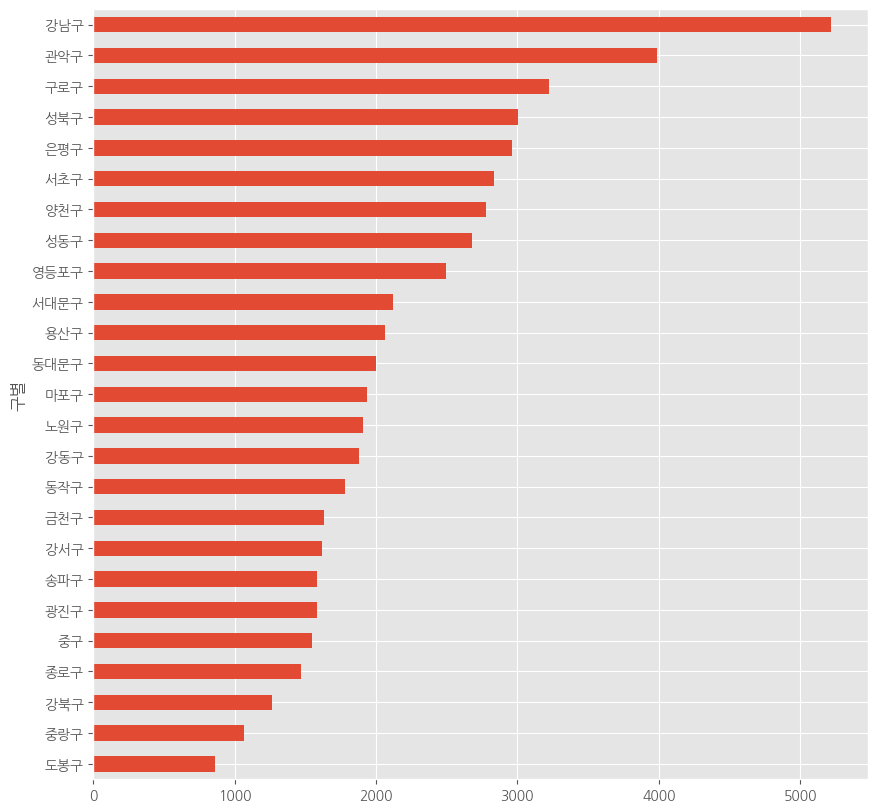

In [33]:
# 소계에 대한 막대 그래프

data_result.소계.sort_values().plot(
  kind='barh',
  grid=True,
  figsize=(10,10)
)



plt.show()

> CCTV댓수는 강남구가 월등하게 많은 것으로 확인

In [40]:
# 인구대비 CCTV 비율

data_result['CCTV비율'] = (data_result['소계'] / data_result['인구수']) * 100

data_result.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율
구별,,,,,,,,,
강남구,5221,52.171379,549898,544804,5094,72602,0.926354,13.202812,0.949449
강동구,1879,82.960078,457042,452646,4396,66401,0.961837,14.528424,0.411122
강북구,1265,83.068017,316750,312985,3765,61660,1.188635,19.466456,0.399369
강서구,1617,77.887789,595703,589302,6401,85992,1.074529,14.435381,0.271444
관악구,3985,99.150425,516662,499374,17288,76664,3.346095,14.838328,0.771297


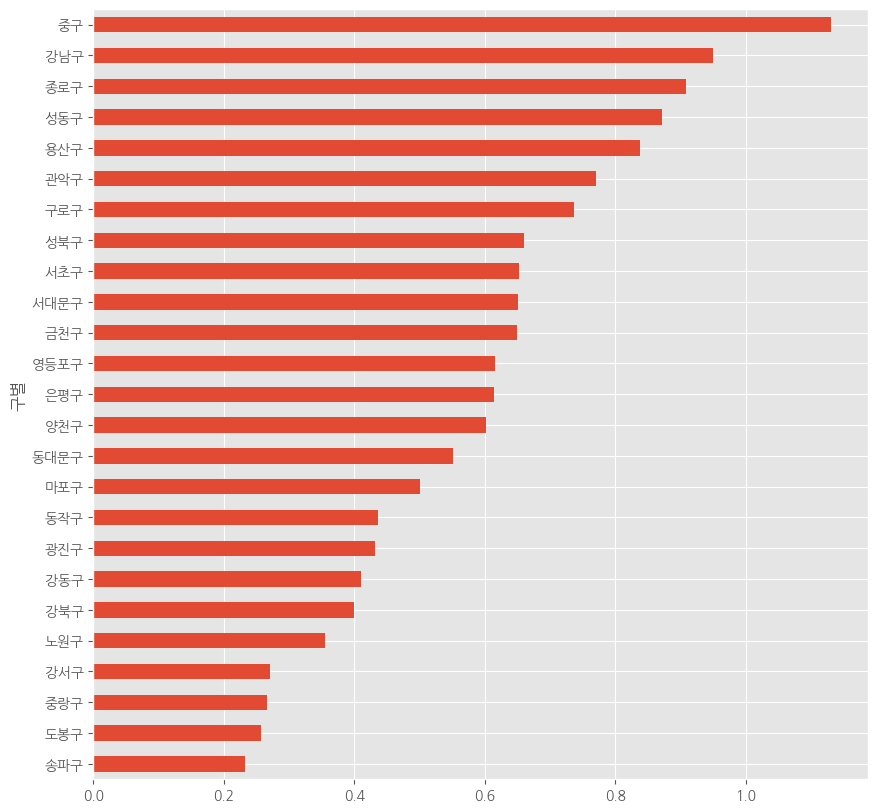

In [41]:
data_result.CCTV비율.sort_values().plot(
  kind='barh',
  grid=True,
  figsize=(10,10)
)



plt.show()

---
### 산점도를 이용한 시각화

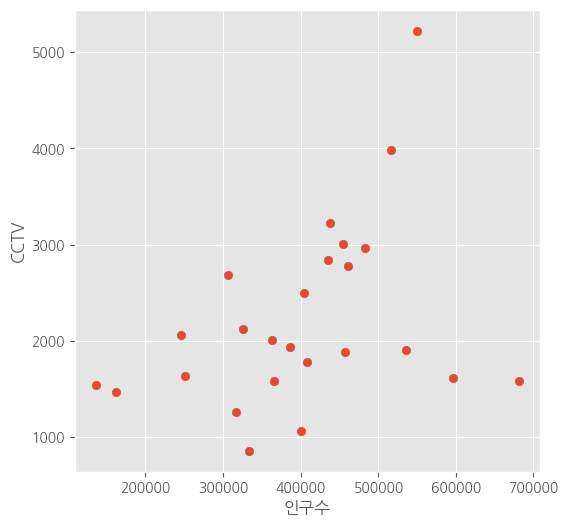

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(
  data_result.인구수,
  data_result.소계
)
plt.xlabel('인구수')
plt.ylabel('CCTV')
# plt.grid()

plt.show()

In [ ]:
# 인구수, 소계에 따른 기준직선(회귀선, 기준선, 중심선) 만들기

fp1 = np.polyfit(
  data_result.인구수,
  data_result.소계,
  1
)

fp1

# 앞이 기울기, 뒤에가 절편

array([2.88522756e-03, 1.06403852e+03])

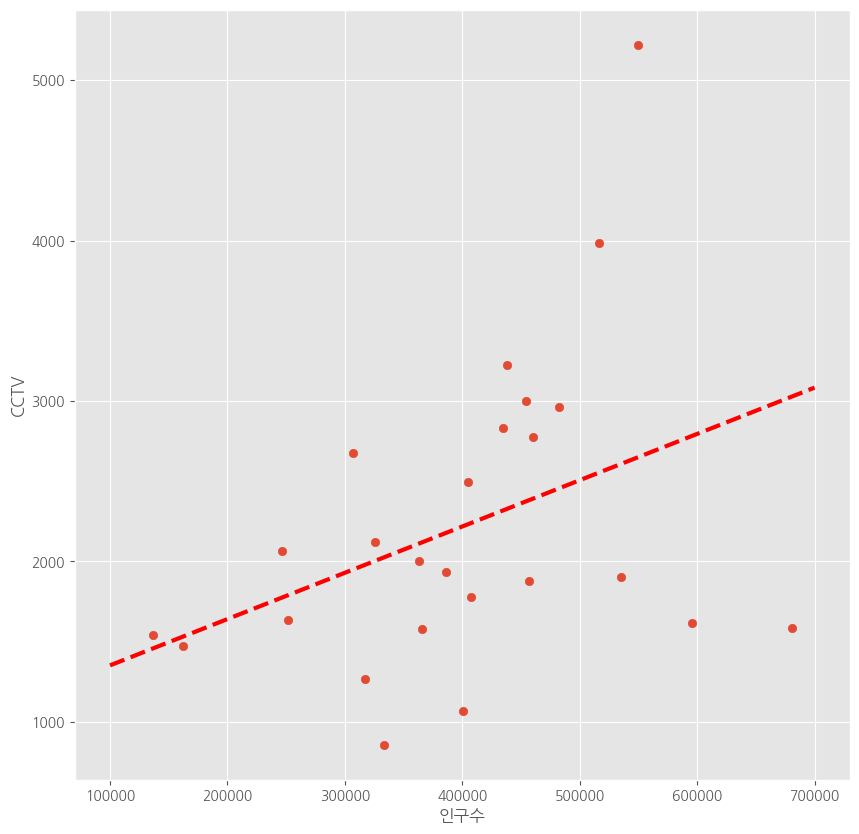

In [50]:
# y축 데이터 만들기 : CCTV소계 표현
f1 = np.poly1d(fp1)

# x축 만들기 : 인구수
fx = np.linspace(100000,700000) # 선으로 만들겠다

plt.figure(figsize=(10,10))
plt.scatter(
  data_result.인구수,
  data_result.소계
)


plt.plot(
  fx,
  f1(fx),
  ls='dashed',
  lw=3,
  color='red' # 보통 회귀선 컬러
)
plt.xlabel('인구수')
plt.ylabel('CCTV')
# plt.grid()

plt.show()

> (결론)

이 직선은 CCTV 댓수의 기준값이 됩니다.

이 직선을 기준으로 상위에 있는 점은 과하게 설치된 것이고

직선보다 하위에 있는 점은 인구수에 비해 CCTV가 부족하다는 해석

---
#### 직선과의 오차를 구하는 공식과 오차의 큰순으로 데이터 정렬 후 그래프 그리기

In [53]:
# 기준선 
fp1 = np.polyfit(
  data_result.인구수,
  data_result.소계,
  1
)

# y축 : CCTV 기준치 구하기
f1 = np.poly1d(fp1)


# x축 : 인구수
fx = np.linspace(100000,700000)


# 소계에서 기준인구수 차이로 오차값 구하기

data_result['오차'] = np.abs(data_result['소계'] - f1(data_result.인구수))

# 정렬
df_sort = data_result.sort_values(
  by='오차',
  ascending=False
)

df_sort.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,오차
구별,,,,,,,,,,
강남구,5221,52.171379,549898,544804,5094,72602,0.926354,13.202812,0.949449,2570.380612
송파구,1586,62.833676,680883,674095,6788,89539,0.996941,13.150424,0.232933,1442.540920
관악구,3985,99.150425,516662,499374,17288,76664,3.346095,14.838328,0.771297,1430.274035
도봉구,858,66.601942,333495,331238,2257,60023,0.676772,17.998171,0.257275,1168.247488
강서구,1617,77.887789,595703,589302,6401,85992,1.074529,14.435381,0.271444,1165.777237


### 그래프에 텍스트와 Color

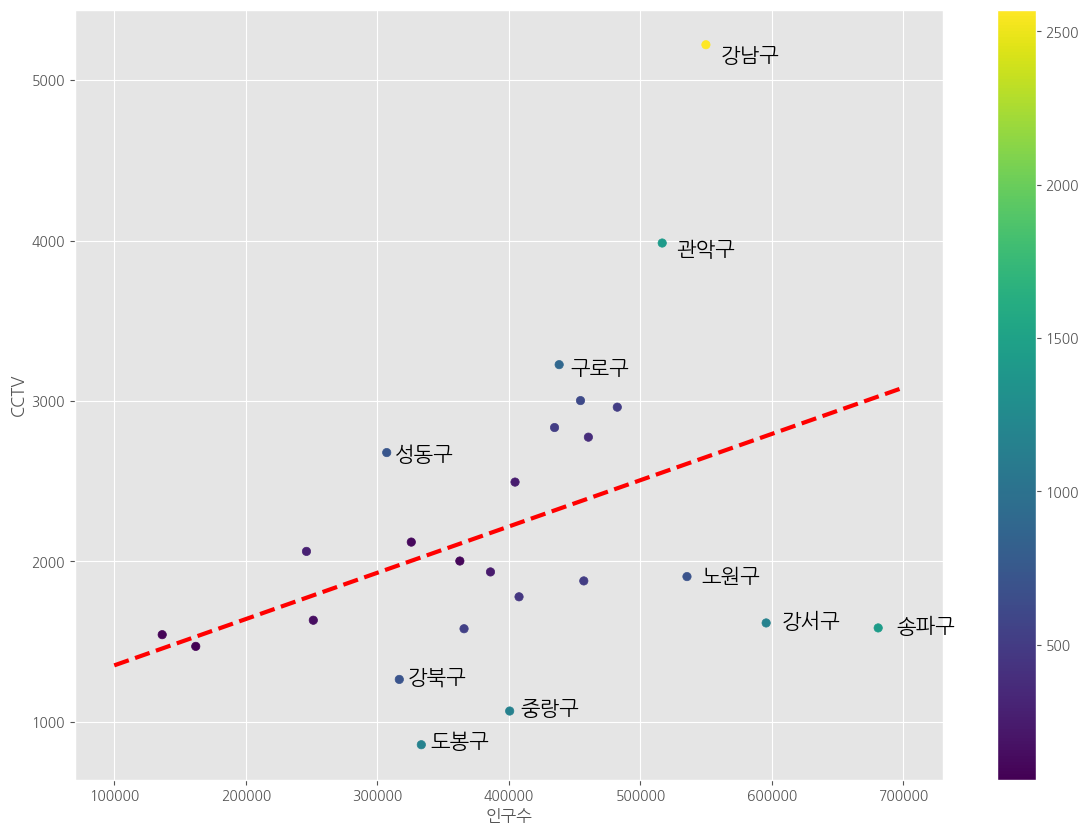

In [59]:
plt.figure(figsize=(14,10))
plt.scatter(
  data_result.인구수,
  data_result.소계,
  c = data_result.오차
)


plt.plot(
  fx,
  f1(fx),
  ls='dashed',
  lw=3,
  color='red' # 보통 회귀선 컬러
)

# 오차가 가장 큰 10개 구에 텍스트 붙이기

for i in range(10):
  plt.text(
    df_sort['인구수'][i]*1.02,
    df_sort['소계'][i]*0.98,
    df_sort.index[i],
    fontsize=15
  )


plt.xlabel('인구수')
plt.ylabel('CCTV')
plt.colorbar()
# plt.grid()

plt.show()